In [1]:
!nvidia-smi

Mon Jul 27 11:42:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               Off |   00000000:01:00.0 Off |                    0 |
| N/A   26C    P0             48W /  350W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
import numpy as np
import xarray as xr
import pickle
import glob
import warnings
from pathlib import Path, PureWindowsPath
import re

import cedalion
import cedalion.sigproc.motion as motion_correct
import cedalion.sigproc.quality as quality
import cedalion.sigproc.physio as physio
import cedalion.dot as dot
import cedalion.nirs as nirs
import cedalion.vis.anatomy
from cedalion.io.forward_model import load_Adot
import cedalion.dot.image_recon as dot_image_recon

from cedalion import units
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
def get_bad_ch_mask(int_data, ch_preproc) -> list:
    # Saturated and Dark Channels
    dark_sat_thresh = [1e-3, 0.84]
    amp_threshs_sat = [0., dark_sat_thresh[1]]
    amp_threshs_low = [dark_sat_thresh[0], 1]
    _, amp_mask_sat = quality.mean_amp(int_data, amp_threshs_sat)
    _, amp_mask_low = quality.mean_amp(int_data, amp_threshs_low)
    _, snr_mask = quality.snr(int_data, 10)
    amp_mask=amp_mask_sat & amp_mask_low

    _, list_bad_ch = quality.prune_ch(int_data, [amp_mask, snr_mask], "all")
   
    return list_bad_ch

# Theekshana
# def get_bad_ch_mask(int_data: xr.DataArray, ch_preproc: dict) -> list:
#     # SCI and PSP Mask    
#     sci, sci_mask = quality.sci(int_data, ch_preproc['window_len'], ch_preproc['sci_thresh'])
#     psp, psp_mask = quality.psp(int_data, ch_preproc['window_len'], ch_preproc['psp_thresh'])

#     sci_psp_mask=sci_mask & psp_mask
#     perc_time_clean = sci_psp_mask.sum(dim="time") / len(sci.time)

#     scipsp_bad_ch=[]
#     for ch in perc_time_clean.channel.values:
#         if perc_time_clean.sel(channel=ch).values < ch_preproc['perc_time_clean']: # dont make the mistake of using the inv condition >:| 
#             scipsp_bad_ch.append(ch)

#     sum_bad_ch = scipsp_bad_ch
#     list_bad_ch = sorted(list(set(sum_bad_ch)))  # remove duplicates

#     print("Flagged Channels : ",len(list_bad_ch), '/', len(int_data.channel))
#     print("Percentage: ", int(len(list_bad_ch) / len(int_data.channel) * 100), '%')
    
#     return list_bad_ch

In [4]:
def standardize_trial_types(DATASET_NAME: str, file: str, stim: pd.DataFrame, rec):
    
    if DATASET_NAME == "FreshMotor":
        # map trial types to left or right depending on the name of the file
        m = re.search(r'(?i)(left|right)', file)

        # rename from MOTOR to left/right
        rec.stim.trial_type = m.group(1).lower()
        # rec.stim = stim
    
    elif DATASET_NAME == "BallSqueezingHD":
        mapping = {
            "Right": "right", # BallSqueezingHD
            "Left": "left",   # BallSqueezingHD
        }
        rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)
        
    elif DATASET_NAME == "BS_Laura":
        stim = stim.copy()
        stim["duration"] = 10.0  # NEW FIX: BS_Laura events are treated as 10s, not the raw 5s annotation
        rec.stim = stim
        
    elif DATASET_NAME == "Electrical_Thermal":
        mapping = {
            "1": "WordCongruent" ,
            "2": "WordIncongruent",
        }
        rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)
        
    elif DATASET_NAME in ["vfc_hd", "Anderson_sparse"]:
        mapping = {
            "1": "WordCongruent" ,
            "2": "WordIncongruent",
        }
        
        rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)
    
    rec.stim.sort_values(by="onset", ignore_index=True, inplace=True)

    # attach/update stim info to rec
    # rec.stim = stim

    return stim, rec


# Select dataset

In [5]:
# Available datasets:
# DATASET_NAME = "BallSqueezingHD_modified"
# DATASET_NAME = "BS_Laura"
DATASET_NAME = "vfc_hd"
# DATASET_NAME = "Anderson_sparse"

# depreicated datasets:
# DATASET_NAME = "ElectricalThermal"
# DATASET_NAME = "FreshMotor"

augmentation_strategy = "base" # base, imageRecon_params
use_subset_channels = True

if use_subset_channels:
    n_channels = 70
    subset_type = f"{n_channels}_chs" # for sparsified versions of a dataset
    sparsified_data_path = f'datasets/pre_processed/base/{DATASET_NAME}/{subset_type}/channel_names__maxDist=4.5__topK=2__randomN=70__70chs.npy'
    print(f"Using sparsified data path: {sparsified_data_path}")
else:
    subset_type = "full"

base_path = "/home/orabe/fNIRS_sparseToDense/"


raw_path = Path(f'datasets/raw/{DATASET_NAME}')

pre_processed_path = Path(f'datasets/pre_processed/{augmentation_strategy}/{DATASET_NAME}/{subset_type}')

pre_processed_path.mkdir(parents=True, exist_ok=True)
print(f"Pre-processed data path: {pre_processed_path}")

Using sparsified data path: datasets/pre_processed/base/vfc_hd/70_chs/channel_names__maxDist=4.5__topK=2__randomN=70__70chs.npy
Pre-processed data path: datasets/pre_processed/base/vfc_hd/70_chs


In [6]:
if DATASET_NAME == "BallSqueezingHD_modified":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"

elif DATASET_NAME == "BS_Laura":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"
    
elif DATASET_NAME == "Electrical_Thermal":
    raw_dir = f"{raw_path}/sub-*/ses-*/nirs/sub-*_ses-*_task-Electrical*_nirs.snirf"
    # TODO: exclude subjects without txt files for landmarks coords
    
elif DATASET_NAME == "FreshMotor":
    duration = "*" # * to include both 2s and 3s
    raw_dir = f"{raw_path}/sub-*/ses-*{duration}/nirs/sub-*_ses-*{duration}_task-FRESHMOTOR_nirs.snirf"
    
elif DATASET_NAME == "vfc_hd":
    # "datasets/raw/vfc_hd/sub-01/nirs/sub-01_ses-02_task-WordStroop_run-01_nirs.snirf"
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"
    
elif DATASET_NAME == "Anderson_sparse":
    # raw_dir = f"{raw_path}/sub-*/ses-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"    

else:
    raise ValueError("Unknown dataset name")

files = glob.glob(raw_dir)

# TODO: to be confirmed
# remove non-BS files for Laura's dataset to avoid errors
if DATASET_NAME == "BS_Laura":
    files = [p for p in files if "BS" in os.path.basename(p)]
    # remove files that has this pattern in the name: _acq-4NN_nirs:
    files = [p for p in files if "_acq-4NN_nirs" not in os.path.basename(p)]
    
files = sorted(files)
print(f"{len(files)} files found.")

17 files found.


In [7]:
files[0]

'datasets/raw/vfc_hd/sub-01/nirs/sub-01_ses-02_task-WordStroop_run-01_nirs.snirf'

In [8]:
filename = files[0] # select one
rec = cedalion.io.read_snirf(filename)[0]

if use_subset_channels:
    # load subset channels from the sparsified data path
    subset_channels = np.load(sparsified_data_path, allow_pickle=True)
    print(f"Loaded subset channels from {sparsified_data_path}")
    print(f"Number of subset channels: {len(subset_channels)}")
    
else:
    all_channels = rec['amp']['channel'].values.tolist()
    subset_channels = all_channels # # make subset_channels equal to all channels
    print(f"Using all channels. Number of channels: {len(subset_channels)}")

rec['amp'] = rec['amp'].sel(channel=subset_channels)
print(f"Selected channels: {len(rec['amp']['channel'])} channels in rec['amp'] after subsetting.")

Loaded subset channels from datasets/pre_processed/base/vfc_hd/70_chs/channel_names__maxDist=4.5__topK=2__randomN=70__70chs.npy
Number of subset channels: 70
Selected channels: 70 channels in rec['amp'] after subsetting.


Plotting montage for 70 channels...


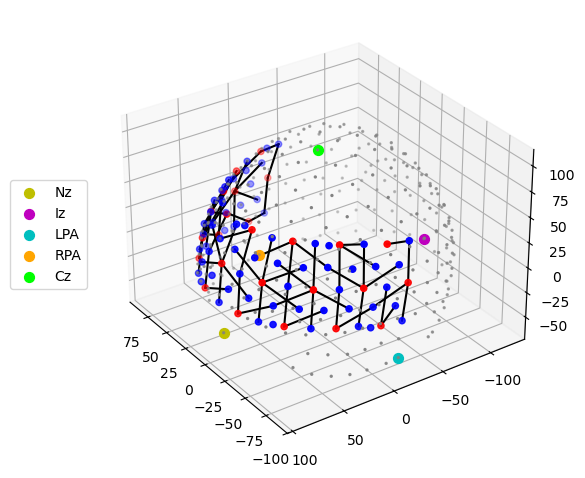

In [9]:
from cedalion.vis.anatomy import plot_montage3D

print(f"Plotting montage for {len(subset_channels)} channels...")
plot_montage3D(rec["amp"], rec.geo3d)

In [10]:
pre_processed_path

PosixPath('datasets/pre_processed/base/vfc_hd/70_chs')

In [ ]:
# new since 13-07-2026: prune channels based on sd_dist
ds_ch, chd_mask = quality.sd_dist(rec["amp"], rec.geo3d, [1, 4.5]*units.cm)
rec['amp'], _ = quality.prune_ch(rec["amp"], [chd_mask], "all")

# subset measurement list
meas_list = rec._measurement_lists["amp"]
meas_list = meas_list[meas_list["channel"].isin(subset_channels)].reset_index(drop=True)

# filter channels based on the valid channels after pruning with sd_dist
meas_list = meas_list[meas_list["channel"].isin(ds_ch[chd_mask].channel.values)].reset_index(drop=True)

# both should then be equal
print(f'Number of channels in rec["amp"]: {len(set(rec["amp"].channel.values))}')
print(f'Number of channels in meas_list: {len(set(meas_list.channel.values))}')


print("Building forward model...")
head_icbm152 = dot.get_standard_headmodel('icbm152')  

if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(rec.geo3d)
    

fwm = cedalion.dot.forward_model.ForwardModel(
    head_icbm152, 
    geo3d_snapped_ijk,
    meas_list
)

fluence_fname = os.path.join(pre_processed_path, "fluence_" + DATASET_NAME + ".h5")
sensitivity_fname = os.path.join(pre_processed_path, "sensitivity_" + DATASET_NAME + ".h5")
print(f"Fluence file: {fluence_fname}")
print(f"Sensitivity file: {sensitivity_fname}")


print("Computing fluence and sensitivity...") # compute fluence & sensitivity only once
# fwm.compute_fluence_mcx(fluence_fname)
# fwm.compute_sensitivity(fluence_fname, sensitivity_fname)

print("Loading sensitivity matrix...")
Adot = load_Adot(sensitivity_fname)
print(f"Adot shape: {Adot.shape}")

print("Creating image reconstruction object...")
recon = dot.ImageRecon(
    Adot,
    recon_mode="mua2conc",
    brain_only=True,
    alpha_meas=10,
    alpha_spatial=10e-3,
    apply_c_meas=True,
    spatial_basis_functions=None,
)
print("Done!")

Number of channels in rec["amp"]: 70
Number of channels in meas_list: 70
Building forward model...
Fluence file: datasets/pre_processed/base/vfc_hd/70_chs/fluence_vfc_hd.h5
Sensitivity file: datasets/pre_processed/base/vfc_hd/70_chs/sensitivity_vfc_hd.h5
Computing fluence and sensitivity...


simulating fluence:   0%|          | 0/91 [00:00<?, ?it/s]

nphoton: 1e+08
tstart: 0
tstep: 5e-09
tend: 5e-09
isnormalized: 1
issrcfrom0: 1
unitinmm: 1
issavedet: 0


###############################################################################
#                      Monte Carlo eXtreme (MCX) -- CUDA                      #
#          Copyright (c) 2009-2025 Qianqian Fang <q.fang at neu.edu>          #
#                https://mcx.space/  &  https://neurojson.io                  #
#                                                                             #
# Computational Optics & Translational Imaging (COTI) Lab- http://fanglab.org #
#   Department of Bioengineering, Northeastern University, Boston, MA, USA    #
###############################################################################
#    The MCX Project is funded by the NIH/NIGMS under grant R01-GM114365      #
###############################################################################
#  Open-source codes and reusable scientific data are essential for research, #
# MCX proudly developed human-readable JSON-based data formats for easy reuse.#
#                                       

nphoton: 1e+08
tstart: 0
tstep: 5e-09
tend: 5e-09
isnormalized: 1
issrcfrom0: 1
unitinmm: 1
issavedet: 0


...

nphoton: 1e+08
tstart: 0
tstep: 5e-09
tend: 5e-09
isnormalized: 1
issrcfrom0: 1
unitinmm: 1
issavedet: 0


###############################################################################
#                      Monte Carlo eXtreme (MCX) -- CUDA                      #
#          Copyright (c) 2009-2025 Qianqian Fang <q.fang at neu.edu>          #
#                https://mcx.space/  &  https://neurojson.io                  #
#                                                                             #
# Computational Optics & Translational Imaging (COTI) Lab- http://fanglab.org #
#   Department of Bioengineering, Northeastern University, Boston, MA, USA    #
###############################################################################
#    The MCX Project is funded by the NIH/NIGMS under grant R01-GM114365      #
###############################################################################
#  Open-source codes and reusable scientific data are essential for research, #
# MCX proudly developed human-readable JSON-based data formats for easy reuse.#
#                                       

nphoton: 1e+08
tstart: 0
tstep: 5e-09
tend: 5e-09
isnormalized: 1
issrcfrom0: 1
unitinmm: 1
issavedet: 0


###############################################################################
#                      Monte Carlo eXtreme (MCX) -- CUDA                      #
#          Copyright (c) 2009-2025 Qianqian Fang <q.fang at neu.edu>          #
#                https://mcx.space/  &  https://neurojson.io                  #
#                                                                             #
# Computational Optics & Translational Imaging (COTI) Lab- http://fanglab.org #
#   Department of Bioengineering, Northeastern University, Boston, MA, USA    #
###############################################################################
#    The MCX Project is funded by the NIH/NIGMS under grant R01-GM114365      #
###############################################################################
#  Open-source codes and reusable scientific data are essential for research, #
# MCX proudly developed human-readable JSON-based data formats for easy reuse.#
#                                       

Loading sensitivity matrix...
Adot shape: (70, 35018, 2)
Creating image reconstruction object...
Done!


In [12]:
print(len(meas_list['channel']))
print(rec["amp"].channel.size)
print(recon._F.shape)
print(Adot.shape)

140
70
(2, 70, 70)
(70, 35018, 2)


Plotting montage for 70 channels...


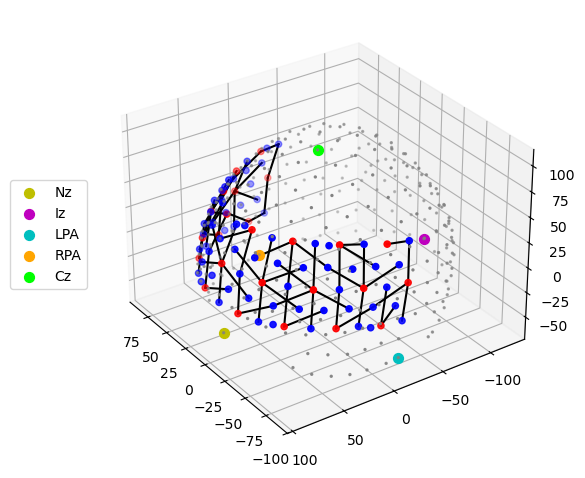

In [13]:
from cedalion.vis.anatomy import plot_montage3D

print(f"Plotting montage for {len(subset_channels)} channels...")
plot_montage3D(rec["amp"], rec.geo3d)

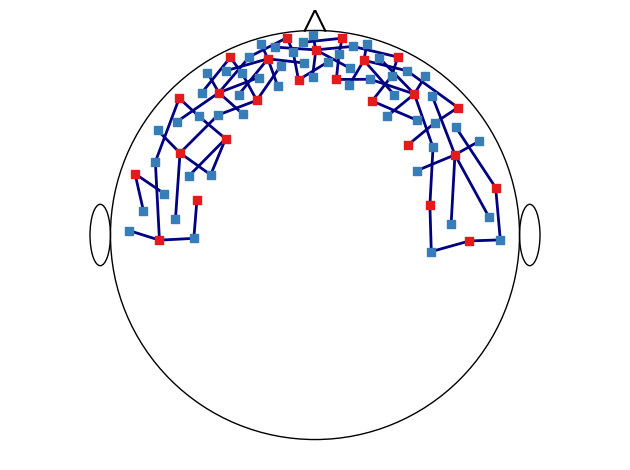

In [14]:
from cedalion.vis.anatomy import plot_montage3D

fig, ax = plt.subplots(1, 1)

cedalion.vis.anatomy.scalp_plot(
    rec['amp'],
    geo3d_snapped_ijk,
    # ninja_aligned,
    np.ones(rec['amp'].channel.size),
    ax,
    cmap="jet",
    title="",
    vmin=1,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)
plt.tight_layout()

In [15]:
# import cedalion.vis.blocks as vbx
# import pyvista as pv
# import cedalion.dataclasses as cdc
# # keep only points that are not of type "landmark", i.e. source and detector points
# geo3d_snapped_ijk = geo3d_snapped_ijk[geo3d_snapped_ijk.type != cdc.PointType.LANDMARK]

# # now we plot the head same as before...
# plt = pv.Plotter()
# vbx.plot_surface(plt, head_icbm152.brain, color="#d3a6a1")
# vbx.plot_surface(plt, head_icbm152.scalp, opacity=.1)
# # but use the plot_labeled_points() function to add the snapped geo3d.
# # The flag "show_labels" can be used to show the source, detector, and landmark names
# vbx.plot_labeled_points(plt, geo3d_snapped_ijk, show_labels=True)
# plt.show()
# # save image
# plt.screenshot("head_with_snapped_points.png")

In [16]:
# import cedalion.vis.blocks as vbx
# from cedalion.io.forward_model import FluenceFile

# # pull fluence values from the corresponding source and detector pair

# with FluenceFile(fluence_fname) as fluence_file:
#     f = fluence_file.get_fluence("S12", 760) * fluence_file.get_fluence("D19", 760)

# f = np.log10(np.clip(f, min=f[f > 0].min()))
# vf = pv.wrap(f)

# plt = pv.Plotter()

# plt.add_volume(
#     vf,
#     log_scale=False,
#     cmap="plasma_r",
#     clim=(-10, -0),
#     scalar_bar_args={
#         "title": r"$log_{10}("
#         r"F(\vec{x}_{src},\vec{x}) * F(\vec{x}, \vec{x}_{det})"
#         ")$"
#     },
# )
# vbx.plot_surface(plt, head_icbm152.brain, color="w")
# vbx.plot_labeled_points(plt, geo3d_snapped_ijk, show_labels=False)
# vbx.camera_at_cog(plt, head_icbm152.brain, rpos=[300, 150, 150])
# plt.show()
# plt.screenshot("fluence_visualization.png")

In [17]:

# import cedalion.vis.anatomy.sensitivity_matrix as sensitivity_matrix

# plotter = sensitivity_matrix.Main(
#     sensitivity=Adot,
#     brain_surface=head_icbm152.brain,
#     head_surface=head_icbm152.scalp,
#     labeled_points=geo3d_snapped_ijk,
# )
# plotter.plot(high_th=0, low_th=-3)
# plotter.plt.show()
# # save the figure
# plotter.plt.screenshot("sensitivity_visualization.png")

## Stim summary

In [18]:
stim = cedalion.io.read_events_from_tsv(files[0].replace('nirs.snirf', 'events.tsv'))
rec.stim = rec.stim.sort_values(by="onset")
stim, rec = standardize_trial_types(DATASET_NAME, files[0], stim, rec)
rec.stim.head()

,onset,duration,value,trial_type
0,18.60,18.0,1.0,WordCongruent
1,50.82,18.0,1.0,WordIncongruent
2,84.17,18.0,1.0,WordIncongruent
3,113.06,18.0,1.0,WordIncongruent
4,139.76,18.0,1.0,WordCongruent


In [19]:
# difference between consecutive onset times
print(np.diff(np.sort(rec.stim.onset.values)))
print(np.min(np.diff(np.sort(rec.stim.onset.values))))

[32.22 33.35 28.89 26.7  27.57 35.   25.17 33.21 28.62 32.81 33.59]
25.169999999999987


In [20]:
pre_process = True

if pre_process:
    from cedalion.io import read_events_from_tsv

    subject_to_rec = {}
    skipped_subjects = []
    

    file_sens_drop_parcels_dict = {}
    for i, f in enumerate (files):
        # if len(subject_to_rec) > 0:
        #     continue
        print(f"--- Processing file: {i+1}/{len(files)} ---")

        if DATASET_NAME == "vfc_hd":
            subj = PureWindowsPath(f).parts[-3]
            if subj == "sub-13":
                continue # skip bad subject

        records = cedalion.io.read_snirf(f)
        rec = records[0]

        # select subset channels
        rec['amp'] = rec['amp'].sel(channel=subset_channels)
        
        # load event files
        stim = read_events_from_tsv(f.replace('nirs.snirf', 'events.tsv'))
        
        # sort
        rec.stim = rec.stim.sort_values(by="onset")
        # stim = stim.sort_values(by="onset")
        
        stim, rec = standardize_trial_types(DATASET_NAME, f, stim, rec)

        # Repair Amp
        rec['rep_amp'] = quality.repair_amp(rec['amp'], median_len=3, method='linear')  
        rec['od_amp'], baseline= nirs.cw.int2od(rec['rep_amp'],return_baseline=True)

        # motion correct [TDDR + WAVELET]
        rec["od_tddr"] = motion_correct.tddr(rec["od_amp"])
        rec["od_tddr_wavel"] = motion_correct.wavelet(rec["od_tddr"])

        # highpass filter
        rec['od_hpfilt'] = rec['od_tddr_wavel'].cd.freq_filter(fmin=0.008,fmax=0,butter_order=4)
        
        # new 13-07-2026: filter channels based on sd_dist
        ds_ch, chd_mask = quality.sd_dist(rec["od_hpfilt"], rec.geo3d, [1, 4.5]*units.cm)
        rec['od_hpfilt'], _ = quality.prune_ch(rec["od_hpfilt"], [chd_mask], "all")

        # clean amplitude data
        rec['amp_clean'] = cedalion.nirs.cw.od2int(rec['od_hpfilt'], baseline)

        # get bad channel mask
        # list_bad_ch = get_bad_ch_mask(rec["amp_clean"]) # this has custom paramerers!? 
        
        ch_preproc = {
            'sci_thresh' : 0.5, # 0.75, # 0.6,    # 0.5 orignal
            'psp_thresh' : 0.1, # 0.03, # 0.08,    # 0.1 orignal
            'window_len' : 5 * units.s,           # 5 seconds
            'dark_sat_thresh' : [1e-3, 0.84],
            'perc_time_clean' : 0.5               # 50 %   
        }  
        list_bad_ch = get_bad_ch_mask(rec["amp_clean"], ch_preproc) # theekshana's
        
        print('the list of bad channels: ', len(list_bad_ch))

        # channel variance
        od_var_vec = quality.measurement_variance(
            rec["od_hpfilt"],
            list_bad_channels=list_bad_ch,
            bad_rel_var=1e6,
            calc_covariance=False
        )
        
        dpf = xr.DataArray(
            [6, 6],
            dims="wavelength",
            coords={"wavelength": rec["amp"].wavelength},
        )
        rec['conc'] = cedalion.nirs.cw.od2conc(rec['od_hpfilt'], rec.geo3d, dpf, spectrum="prahl")

        # conc_pr vs conc 
        try:
            chromo_var = quality.measurement_variance(
                rec['conc'],
                list_bad_channels = list_bad_ch,
                bad_rel_var = 1e6,
                calc_covariance = False
        )
        except Exception as e:
            print(f"Skipping file {f} due to error in chromo_var calculation: {e}")
            skipped_subjects.append(f)
            continue
        
        rec['conc_pcr'], gb_comp_rem = physio.global_component_subtract(
            rec['conc'],
            ts_weights=1/chromo_var,
            k=0,
            spatial_dim='channel',
            spectral_dim='chromo'
        )

        rec['od_pcr1'] = cedalion.nirs.cw.conc2od(rec['conc_pcr'], rec.geo3d, dpf, spectrum="prahl")    # delta_conc = chunked_eff_xr_matmult(od_stacked, B, contract_dim="flat_channel", sample_dim="time", chunksize=300)
        
        c_meas = quality.measurement_variance(
            rec['od_hpfilt'],
            list_bad_channels=list_bad_ch,
            bad_rel_var=1e6,
            calc_covariance=False
        )

        delta_conc = recon.reconstruct(rec['od_pcr1'], c_meas) 
        delta_conc.time.attrs["units"] = units.s

        dC_brain = delta_conc.cd.freq_filter(fmin=0.01, fmax=0.5, butter_order=4)
        dC_brain = dC_brain.sel(
            time=slice(rec.stim.onset.values[0] - 3,
                       rec.stim.onset.values[-1] + 13)
            )
        dC_brain = dC_brain.where(dC_brain.is_brain == True)
        # alternatively use 1/conc_var to weight vertex sensitivity and then normalize by sum of weights
        dC_brain = dC_brain.pint.quantify().pint.to("uM").pint.dequantify()

        hbr = dC_brain.sel(chromo='HbR').groupby('parcel').mean()
        hbo = dC_brain.sel(chromo='HbO').groupby('parcel').mean()
        signal_raw = xr.concat([hbo, hbr], dim='chromo')

        # revised matrix
        signal_raw = signal_raw.sel(parcel=signal_raw.parcel != 'Background+FreeSurfer_Defined_Medial_Wall_LH')
        signal_raw = signal_raw.sel(parcel=signal_raw.parcel != 'Background+FreeSurfer_Defined_Medial_Wall_RH')
        
        delta_conc, global_comp = physio.global_component_subtract(
            signal_raw, 
            ts_weights=None,
            k=0, 
            spatial_dim='parcel',
            spectral_dim= 'chromo')

        delta_conc = delta_conc / np.abs(delta_conc).max()
        delta_conc = delta_conc.fillna(0)
        delta_conc = delta_conc.transpose("time", "parcel", "chromo")

        parcel_dOD, parcel_mask = fwm.parcel_sensitivity(
            Adot,
            [], # list_bad_ch,
            dOD_thresh = 0.001,       
            minCh=1,
            dHbO=10,
            dHbR=-3
        )
        sensitive_parcels = parcel_mask.where(parcel_mask, drop=True)["parcel"].values.tolist()
        dropped_parcels = parcel_mask.where(~parcel_mask, drop=True)["parcel"].values.tolist()
        file_sens_drop_parcels_dict[f] = {
            "sensitive_parcels": sensitive_parcels,
            "dropped_parcels": dropped_parcels
        }
        print(f"Number of sensitive parcels: {len(sensitive_parcels)}")
        print(f"Number of dropped parcels: {len(dropped_parcels)}")
        
        total_parcels = len(sensitive_parcels) + len(dropped_parcels)
        dropped_ratio = (len(dropped_parcels) / total_parcels) if total_parcels else 1.0
        
        print(f"Dropped parcels ratio: {dropped_ratio:.2f}")
        if dropped_ratio > 0.99:
            print(f"Skipping {f}: dropped {len(dropped_parcels)} / {total_parcels}, remaining {len(sensitive_parcels)}")
            skipped_subjects.append(f)
            continue
            
        data = {
            'conc_pcr': rec['conc_pcr'],
            'od_pcr1': rec['od_pcr1'],
            'delta_conc': delta_conc,
            'rec_stim': rec.stim,
            'sensitive_parcels': sensitive_parcels,
        }
        
        # save as pickle (all parcels!!!)
        path = PureWindowsPath(f)
        subject_dir = path.parts[-3]
        filename = path.stem

        if DATASET_NAME == "FreshMotor":
            subject_dir = path.parts[-4]
            session_label = path.parts[-3]
            task_fragment = next(
                (part for part in filename.split('_') if part.startswith('task-')),
                f"task-{DATASET_NAME.replace('_', '').upper()}",
            )
            run_fragment = session_label.replace('ses-', 'run-')
            filename = f'{subject_dir}_{task_fragment}_{run_fragment}_nirs'

        if subject_dir not in subject_to_rec:
            subject_to_rec[subject_dir] = []

        all_parcels_dir = pre_processed_path / subject_dir
        all_parcels_dir.mkdir(parents=True, exist_ok=True)

        file_name_to_save = all_parcels_dir / f'{filename}.pkl'

        with open(file_name_to_save, 'wb') as handle:
            pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)
        
    if skipped_subjects:
        print(f"Skipped {len(skipped_subjects)} file(s)")

    print("\nProcessing complete.")

    with open(pre_processed_path / "file_sens_drop_parcels_dict.pkl", 'wb') as handle:
        pickle.dump(file_sens_drop_parcels_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)  
    print(f"Saved file_sens_drop_parcels_dict to {pre_processed_path / 'file_sens_drop_parcels_dict.pkl'}")

--- Processing file: 1/17 ---
the list of bad channels:  12
Number of sensitive parcels: 145
Number of dropped parcels: 456
Dropped parcels ratio: 0.76
--- Processing file: 2/17 ---
the list of bad channels:  9
Number of sensitive parcels: 145
Number of dropped parcels: 456
Dropped parcels ratio: 0.76
--- Processing file: 3/17 ---
the list of bad channels:  4
Number of sensitive parcels: 145
Number of dropped parcels: 456
Dropped parcels ratio: 0.76
--- Processing file: 4/17 ---
the list of bad channels:  6
Number of sensitive parcels: 145
Number of dropped parcels: 456
Dropped parcels ratio: 0.76
--- Processing file: 5/17 ---
the list of bad channels:  13
Number of sensitive parcels: 145
Number of dropped parcels: 456
Dropped parcels ratio: 0.76
--- Processing file: 6/17 ---
the list of bad channels:  17
Number of sensitive parcels: 145
Number of dropped parcels: 456
Dropped parcels ratio: 0.76
--- Processing file: 7/17 ---
--- Processing file: 8/17 ---
the list of bad channels:  19
N

In [21]:
# # load data for visualization
# if DATASET_NAME == "BallSqueezingHD_modified":
#     subject_name = 'sub-185'
#     file_name = f'{subject_name}_task-BallSqueezing_run-3_nirs.pkl'
#     file_to_plot = pre_processed_path / subject_name / file_name
    
# elif DATASET_NAME == "FreshMotor":
#     subject_name = 'sub-01'
#     file_name = f'{subject_name}_task-FRESHMOTOR_run-left2s_nirs.pkl'
#     file_to_plot = pre_processed_path / subject_name / file_name

# elif DATASET_NAME == "BS_Laura":
#     subject_name = 'sub-538'
#     file_name = f'{subject_name}_task-BS_run-01_nirs.pkl'
#     file_to_plot = pre_processed_path / subject_name / file_name
# elif DATASET_NAME == "vfc_hd":
#     subject_name = 'sub-12'
#     file_name = f'{subject_name}_ses-01_task-WordStroop_run-01_nirs.pkl'
#     file_to_plot = pre_processed_path / subject_name / file_name
# elif DATASET_NAME == "Anderson_sparse":
#     subject_name = 'sub-1'
#     file_name = f'{subject_name}_ses-1_task-WordStroop_run-1_nirs.pkl'
#     file_to_plot = pre_processed_path / subject_name / file_name    
    
# # load data
# with open(file_to_plot, 'rb') as handle:
#     data = pickle.load(handle)

# Calculate block averages in optical density



Blockaverage od_pcr1

In [22]:
# import matplotlib.pyplot as p

# # segment data into epochs
# if DATASET_NAME in ["BallSqueezingHD_modified", "BS_Laura"]:
#     epochs = rec['od_pcr1'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["left", "right"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
# elif DATASET_NAME == "FreshMotor":
#     epochs = rec['od_pcr1'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["right"],  # select left/right events
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
# elif DATASET_NAME in ["vfc_hd", "Anderson_sparse"]:
#     epochs = rec['od_pcr1'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["WordCongruent", "WordIncongruent"],
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
    
# # calculate baseline
# baseline = epochs.sel(reltime=(epochs.reltime < 0)).mean("reltime")

# # subtract baseline
# epochs_blcorrected = epochs - baseline

# # group trials by trial_type. For each group individually average the epoch dimension
# blockaverage_od_pcr1 = epochs_blcorrected.groupby("trial_type").mean("epoch")

In [23]:
# from IPython.display import Image
# def display_image(fname : str):
#     display(Image(data=open(fname,'rb').read(), format='png'))

In [24]:
# results_path_prefix = f'results/{subset_type}/{DATASET_NAME}/{subject_name}'
# os.makedirs(results_path_prefix, exist_ok=True)

In [25]:
# # Plot block averages. Please ignore errors if the plot is too small in the HD case

# filename = f"results/{subset_type}/{DATASET_NAME}/blockaverage_channel_space_{subset_type}.png"

# noPlts2 = int(np.ceil(np.sqrt(len(blockaverage_od_pcr1.channel))))
# f,ax = p.subplots(noPlts2,noPlts2, figsize=(12,10))
# ax = ax.flatten()
# for i_ch, ch in enumerate(blockaverage_od_pcr1.channel):
#     for ls, trial_type in zip(["-", "--"], blockaverage_od_pcr1.trial_type):
#         ax[i_ch].plot(blockaverage_od_pcr1.reltime, blockaverage_od_pcr1.sel(wavelength=760, trial_type=trial_type, channel=ch), "r", lw=2, ls=ls)
#         ax[i_ch].plot(blockaverage_od_pcr1.reltime, blockaverage_od_pcr1.sel(wavelength=850, trial_type=trial_type, channel=ch), "b", lw=2, ls=ls)

#     ax[i_ch].grid(1)
#     ax[i_ch].set_title(ch.values)
#     ax[i_ch].set_ylim(-.02, .02)
#     ax[i_ch].set_axis_off()
#     ax[i_ch].axhline(0, c="k")
#     ax[i_ch].axvline(0, c="k")

# # p.suptitle("760nm: r | 850nm: b | left: - | right: --")
# p.suptitle("HbO: r | HbR: b | left: - | right: --")

# p.tight_layout()
# p.savefig(filename)

In [26]:
def match_landmark_labels(rec):
    subject_nasion_mask = rec.geo3d['label'].data == 'NASION'

    new_labels = rec.geo3d['label'].data.copy()
    new_labels[subject_nasion_mask] = 'Nz'

    # Create new geo3d with updated labels
    rec.geo3d = rec.geo3d.assign_coords(label=new_labels)
    # print(rec.geo3d['label'].data)

    return rec

In [27]:
rec = match_landmark_labels(rec)
rec.stim.head()

,onset,duration,value,trial_type
0,24.313856,10.0,1.0,WordIncongruent
1,54.304768,10.0,1.0,WordCongruent
2,85.327872,10.0,1.0,WordIncongruent
3,116.350976,10.0,1.0,WordIncongruent
4,148.348928,10.0,1.0,WordCongruent


In [28]:
# # Viz reconstruction on Channel Space
# import cedalion.vis.anatomy
# filename_scalp = f"results/{subset_type}/{DATASET_NAME}/scalp_plot_ts_{subset_type}.png"

# # data_ts = blockaverage_od_pcr1.sel(wavelength=850, trial_type="right")
# data_ts = blockaverage_od_pcr1.sel(wavelength=850, trial_type="WordCongruent")
# # scalp_plot_gif expects the time dimension to be named 'time'
# data_ts = data_ts.rename({"reltime": "time"})

# # call plot function 
# cedalion.vis.anatomy.scalp_plot_gif(
#     data_ts,
#     rec.geo3d,
#     filename=filename_scalp,
#     time_range=(-5, 30, 0.5) * units.s,
#     scl=(-0.01, 0.01),
#     fps=6,
#     optode_size=6,
#     optode_labels=True,
#     str_title="OD 850 nm",
# )
# display_image(f"{filename_scalp}.gif")

Blockaverage_delta_conc

In [29]:
# if DATASET_NAME == "BallSqueezingHD_modified" or DATASET_NAME == "BS_Laura":
#     epochs = data['delta_conc'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["left", "right"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
# elif DATASET_NAME == "FreshMotor":
#     # segment data into epochs
#     epochs = data['delta_conc'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["right"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
    
# elif DATASET_NAME in ["vfc_hd", "Anderson_sparse"]:
#     # segment data into epochs
#     epochs = data['delta_conc'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["WordCongruent", "WordIncongruent"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )    

# # calculate baseline
# baseline = epochs.sel(reltime=(epochs.reltime < 0)).mean("reltime")

# # subtract baseline
# epochs_blcorrected = epochs - baseline

# # group trials by trial_type. For each group individually average the epoch dimension
# blockaverage_delta_conc = epochs_blcorrected.groupby("trial_type").mean("epoch")

In [30]:
# vertex_parcels = head_icbm152.brain.vertex_coords['parcel']
# vertex_parcels = np.array(vertex_parcels)

# parcel_index = blockaverage_delta_conc.get_index("parcel")  # pandas index
# vertex_parcel_idx = parcel_index.get_indexer(vertex_parcels)

# parcel_data = blockaverage_delta_conc.values  # shape (2, 107, 601, 2)

# # Broadcast using integer indexing on axis=2 (parcel axis)
# vertex_activity = parcel_data[:, :, vertex_parcel_idx, :]

# n_vertices = len(vertex_parcel_idx)

# vertex_da = xr.DataArray(
#     vertex_activity,
#     dims=("trial_type", "reltime", "vertex", "chromo"),
#     coords=dict(
#         trial_type=blockaverage_delta_conc.trial_type,
#         reltime=blockaverage_delta_conc.reltime,
#         chromo=blockaverage_delta_conc.chromo,

#         # vertex index
#         vertex=np.arange(n_vertices),

#         # parcel label of each vertex
#         parcel_of_vertex=("vertex", vertex_parcels),

#         # NEW: is_brain flag
#         is_brain=("vertex", np.ones(n_vertices, dtype=bool))
#     )
# )

# vertex_da.shape

In [31]:
# filename_multiview = f'{results_path_prefix}/image_recon_multiview_{subset_type}'

# # prepare data
# # X_ts = vertex_da.sel(trial_type="right").rename({"reltime": "time"})
# X_ts = vertex_da.sel(trial_type="WordCongruent").rename({"reltime": "time"})
# X_ts = X_ts.transpose("vertex", "chromo", "time")

# scl = np.percentile(np.abs(X_ts.sel(chromo='HbO')).pint.dequantify(), 99)
# clim = (-scl,scl)

# cedalion.vis.anatomy.image_recon_multi_view(
#     X_ts,  # time series data; can be 2D (static) or 3D (dynamic)
#     head_icbm152,
#     cmap='seismic',
#     clim=clim,
#     view_type='hbo_brain',
#     title_str='HbO / µM',
#     filename=filename_multiview,
#     SAVE=True,
#     time_range=(-2,10,0.5)*units.s,
#     fps=6,
#     geo3d_plot = None, #  geo3d_plot
#     wdw_size = (1024, 768)
# )
# display_image(filename_multiview+'.gif')

# Segmentation

In [32]:
pre_processed_path

PosixPath('datasets/pre_processed/base/vfc_hd/70_chs')

In [33]:
# load (all) parcel files
preproc_files_path = str(pre_processed_path / 'sub-*' / '*.pkl')
proc_pkl_files = glob.glob(preproc_files_path)

len(proc_pkl_files), proc_pkl_files[:2]

(16,
 ['datasets/pre_processed/base/vfc_hd/70_chs/sub-09/sub-09_ses-01_task-WordStroop_run-01_nirs.pkl',
  'datasets/pre_processed/base/vfc_hd/70_chs/sub-12/sub-12_ses-01_task-WordStroop_run-01_nirs.pkl'])

### Compute template sensitive parcels

In [34]:
create_orload_parcel_template = "load"  # "load" or "create"

if create_orload_parcel_template == "create":
    # Load any file as all processed files have the same sensitive parcels    
    if DATASET_NAME == "BallSqueezingHD_modified":
        f = f"datasets/pre_processed/base/BallSqueezingHD_modified/full/sub-185/sub-185_task-BallSqueezing_run-1_nirs.pkl"    
    elif DATASET_NAME == "BS_Laura":
        f = f"datasets/pre_processed/base/BS_Laura/full/sub-568/sub-568_task-BS_run-01_nirs.pkl"
    elif DATASET_NAME == "vfc_hd":
        f = f"datasets/pre_processed/base/vfc_hd/full/sub-01/sub-01_ses-02_task-WordStroop_run-01_nirs.pkl"
    elif DATASET_NAME == "Anderson_sparse":
        f = f"datasets/pre_processed/base/Anderson_sparse/full/sub-1/sub-1_ses-1_task-WordStroop_run-1_nirs.pkl"
    
    sens_parcel_template_path = f"datasets/pre_processed/base/{DATASET_NAME}/full/parcel_template_{DATASET_NAME}.pkl"
    
    with open(f, 'rb') as handle:
        data = pickle.load(handle)        
    print(f"Number of sensitive parcels: {len(data['sensitive_parcels'])}")

    # save the loaded sensitive parcels as template as pkl file   
    with open(sens_parcel_template_path, 'wb') as handle:
        pickle.dump(data['sensitive_parcels'], handle)
    
    print(f"Parcel template saved to {sens_parcel_template_path}")
        
elif create_orload_parcel_template == "load":
    """
    Load BallsqueezingHD_modified parcel template when we process:
        - BallsqueezingHD_modified
        - BS_Laura

    Load Anderson_sparse parcel template when we process:
        - Anderson_sparse
        - vfc_hd
    """
    # Optionally, as a sanity check, we can load any template file
    # sens_parcel_template_path = f'datasets/pre_processed/base/vfc_hd/full/parcel_template_vfc_hd.pkl'
    
    # sens_parcel_template_path = f'datasets/pre_processed/base/BS_Laura/full/parcel_template_BS_Laura.pkl'
    
    # BUT for the purpose of this code, we will load the base templates:
    # Load this template for BallSqueezingHD_modified and BS_Laura datasets
    
    # sens_parcel_template_path = f'datasets/pre_processed/base/BallSqueezingHD_modified/full/parcel_template_BallSqueezingHD_modified.pkl'
    
    # Or load this template for Anderson_sparse and vfc_hd datasets
    sens_parcel_template_path = f'datasets/pre_processed/base/Anderson_sparse/full/parcel_template_Anderson_sparse.pkl'

    with open(sens_parcel_template_path, 'rb') as handle:
        template_sens_parcel_list = pickle.load(handle)
        
    print(f"Number of sensitive parcels in template: {len(template_sens_parcel_list)}")
    print(f"Parcel template loaded from {sens_parcel_template_path}")

Number of sensitive parcels in template: 136
Parcel template loaded from datasets/pre_processed/base/Anderson_sparse/full/parcel_template_Anderson_sparse.pkl


### check template

In [35]:
#NOTE: Run this cell only when we want to load the data in case we started running this notebook without running the pre-processing code above. 

# file_sens_drop_parcels_dict_path = "datasets/pre_processed/base/BallSqueezingHD_modified/full/file_sens_drop_parcels_dict.pkl"
# file_sens_drop_parcels_dict_path = "datasets/pre_processed/base/Anderson_sparse/full/file_sens_drop_parcels_dict.pkl"

# file_sens_drop_parcels_dict_path = "datasets/pre_processed/base/BS_Laura/50_chs/file_sens_drop_parcels_dict.pkl"

# with open(file_sens_drop_parcels_dict_path, 'rb') as handle:
#     file_sens_drop_parcels_dict = pickle.load(handle)
#     print(f"Loaded {file_sens_drop_parcels_dict_path}")
    
# pkl_f = "datasets/pre_processed/base/BS_Laura/73_chs/sub-568/sub-568_task-BS_run-01_nirs.pkl"

# with open(pkl_f, 'rb') as handle:
#     data = pickle.load(handle)


In [36]:
print(data['conc_pcr'].shape)
print(data['delta_conc'].shape)

count = 0
for i, parcel in enumerate(data['sensitive_parcels']):
    if parcel in template_sens_parcel_list:
        count += 1
print(f"Total sensitive parcels in data: {len(data['sensitive_parcels'])}")
print(f"Total sensitive parcels in template: {len(template_sens_parcel_list)}")
print(f"Number of sensitive parcels in data that are in template: {count}")

(2, 70, 10319)
(9578, 601, 2)
Total sensitive parcels in data: 145
Total sensitive parcels in template: 136
Number of sensitive parcels in data that are in template: 132


In [37]:
# Check how many of the sensitive parcels from the dictionary are contained in the template parcel list.

with open(sens_parcel_template_path, 'rb') as handle:
    template_sens_parcel_list = pickle.load(handle)
    
print(f"Length of template sensitive parcels: {len(template_sens_parcel_list)}")

# for each subject, check how many of the sensitive parcels from the dictionary are contained in the template parcel list
for i, (f, sens_drop_info) in enumerate(file_sens_drop_parcels_dict.items()):
    sensitive_parcels = sens_drop_info['sensitive_parcels']
    dropped_parcels = sens_drop_info['dropped_parcels']
    
    num_sensitive_in_template = sum(1 for parcel in sensitive_parcels if parcel in template_sens_parcel_list)
    num_dropped_in_template = sum(1 for parcel in dropped_parcels if parcel in template_sens_parcel_list)
    
    # print(f"File: {f}")
    print(f"{i+1} - Sensitive parcels in template: {num_sensitive_in_template} / {len(template_sens_parcel_list)}")


Length of template sensitive parcels: 136
1 - Sensitive parcels in template: 132 / 136
2 - Sensitive parcels in template: 132 / 136
3 - Sensitive parcels in template: 132 / 136
4 - Sensitive parcels in template: 132 / 136
5 - Sensitive parcels in template: 132 / 136
6 - Sensitive parcels in template: 132 / 136
7 - Sensitive parcels in template: 132 / 136
8 - Sensitive parcels in template: 132 / 136
9 - Sensitive parcels in template: 132 / 136
10 - Sensitive parcels in template: 132 / 136
11 - Sensitive parcels in template: 132 / 136
12 - Sensitive parcels in template: 132 / 136
13 - Sensitive parcels in template: 132 / 136
14 - Sensitive parcels in template: 132 / 136
15 - Sensitive parcels in template: 132 / 136
16 - Sensitive parcels in template: 132 / 136


In [38]:
# check how many of the sensitive parcels are motor are
motor_labels = [l for l in template_sens_parcel_list if l.startswith("SomMot")]
print(f"{len(motor_labels)} motor labels")

30 motor labels


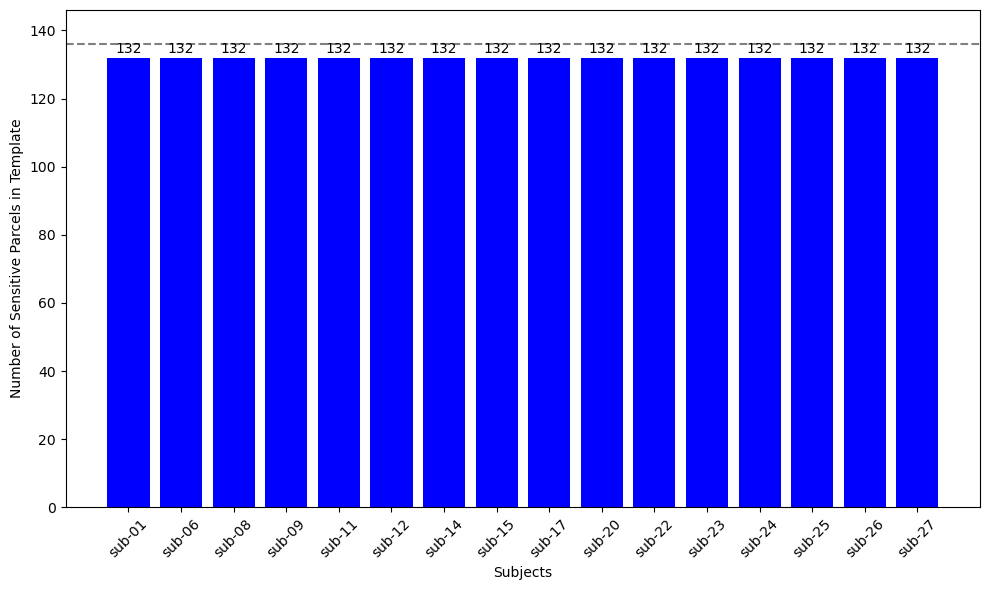

In [39]:
import matplotlib.pyplot as plt
# Plot as barplot the number of sensitive parcels in the template for each subject
files = list(file_sens_drop_parcels_dict.keys())
num_sensitive_in_template_list = []
for f in files:
    sensitive_parcels = file_sens_drop_parcels_dict[f]['sensitive_parcels']
    num_sensitive_in_template = len(set(sensitive_parcels) & set(template_sens_parcel_list))
    num_sensitive_in_template_list.append(num_sensitive_in_template)
plt.figure(figsize=(10, 6))
plt.bar(range(len(files)), num_sensitive_in_template_list, color='blue')
# print the number of sensitive parcels in the template for each subject on top of the bars
for i, num in enumerate(num_sensitive_in_template_list):    
    plt.text(i, num + 0.5, str(num), ha='center', va='bottom')
# plt.plot(range(len(files)), num_sensitive_in_template_list, color='red')
plt.xticks(range(len(files)), [f.split('/')[3].replace('.snirf', '') for f in files], rotation=45)
plt.xlabel('Subjects')
plt.ylabel('Number of Sensitive Parcels in Template')
plt.ylim(0, len(template_sens_parcel_list) + 10)
plt.axhline(y=len(template_sens_parcel_list), color='gray', linestyle='dashed')
# plt.legend()
# plt.title('Sensitive Parcels in Template for Each Subject')
plt.tight_layout()
plt.show()

In [40]:
processed_path = Path(f'datasets/processed/{augmentation_strategy}/{DATASET_NAME}/{subset_type}')
processed_path.mkdir(parents=True, exist_ok=True)
processed_path

PosixPath('datasets/processed/base/vfc_hd/70_chs')

In [41]:
from collections import Counter

# load (all) parcel files
preproc_files_path = str(pre_processed_path / 'sub-*' / '*.pkl')
proc_pkl_files = glob.glob(preproc_files_path)

print(f"Number of processed pickle files: {len(proc_pkl_files)}")
print(f"First 2 processed pickle files: {proc_pkl_files[:2]}")

# Gather all fs_mean values from all files
fs_list = []
for file in proc_pkl_files:
    with open(file, 'rb') as handle:
        data_pickle = pickle.load(handle)
    delta_brain = data_pickle['delta_conc']
    
    dt = np.diff(delta_brain.time.data)
    fs_mean = float(1.0 / np.mean(dt))
    
    fs_list.append(fs_mean)

fs_counts = Counter(fs_list)

print(f"Frequency of sampling rates:")
for fs, count in fs_counts.items():
    print(f"Sampling Rate: {fs} Hz, Count: {count}")

Number of processed pickle files: 16
First 2 processed pickle files: ['datasets/pre_processed/base/vfc_hd/70_chs/sub-09/sub-09_ses-01_task-WordStroop_run-01_nirs.pkl', 'datasets/pre_processed/base/vfc_hd/70_chs/sub-12/sub-12_ses-01_task-WordStroop_run-01_nirs.pkl']
Frequency of sampling rates:
Sampling Rate: 17.438616071428573 Hz, Count: 12
Sampling Rate: 17.438616071428577 Hz, Count: 4


In [42]:
with open(file, 'rb') as handle:
    data_pickle = pickle.load(handle)

conc_pcr = data_pickle['conc_pcr']
delta_brain = data_pickle['delta_conc']
sensitive_parcels = data_pickle['sensitive_parcels']
rec_stim = data_pickle['rec_stim']

conc_pcr

Magnitude,[[[-0.04573706031032475 -0.017136602603416793 -0.023800335251624595 ... -0.19169562992908032 -0.1786912496147691 -0.11801961937924313] [-0.03070697370500208 -0.11901925350816035 -0.14553468033971861 ... 0.2766158621965903 0.1422645987208525 0.09247713989773539] [0.14774194000833174 0.18426076578284029 -0.40544702145757167 ... 0.3991222605980649 0.49296183430567986 0.24126935517327197] ... [0.13590113219894334 0.14572311007827587 0.20288516004208695 ... 0.10678666597245426 -0.029958284489502746 -0.21790975347104405] [-0.39114334681113017 -0.15947215539153634 -0.21221405693867634 ... -1.1384407832441483 -0.9859768801464672 -0.7702683079290273] [-0.27671724667868064 -0.28787233742255586 -0.3489500645557438 ... -0.5387615032529882 -0.5711337040022522 -0.3957936606104081]] [[-0.01052682918585372 0.020285971192492796 0.024586789570319255 ... 0.015799744677628416 0.018810190388389443 0.0352285454977664] [0.011236478532230504 -0.015106033442745595 0.020601972408660657 ... -0.023800796673753802 0.003777282553589875 -0.02022243219231956] [-0.16225070929582516 -0.13640874757962243 0.01807340418869162 ... -0.6349614705444928 -0.6910828629787709 -0.32544922105566054] ... [0.025295201165544567 0.010866123411113936 0.024999323531654915 ... -0.1015250723762702 -0.11929539622082941 -0.049621224115773716] [0.044721939886229925 0.07706422937197754 0.0949542930678928 ... -0.3683182298523044 -0.33245929621237025 -0.26125084702774837] [0.02511576198089288 0.05319899845404848 0.0977149137389572 ... -0.23655967262410965 -0.22327326946045944 -0.12300221593030441]]]
Units,micromolar


In [43]:
delta_brain.sel(parcel=template_sens_parcel_list)

<xarray.DataArray (time: 9582, parcel: 136, chromo: 2)> Size: 21MB
array([[[-0.03046374,  0.01370644],
        [ 0.12732958, -0.15113972],
        [-0.02766909, -0.01838849],
        ...,
        [-0.04766556, -0.01446999],
        [-0.02907348,  0.01537607],
        [-0.04654837,  0.02963993]],

       [[-0.03008315,  0.01424221],
        [ 0.12467159, -0.15258829],
        [-0.02727625, -0.01855998],
        ...,
        [-0.04761654, -0.01275051],
        [-0.02772304,  0.0156617 ],
        [-0.04701553,  0.03055238]],

       [[-0.02979038,  0.01477875],
        [ 0.12169498, -0.15355843],
        [-0.02681402, -0.01870885],
        ...,
...
        ...,
        [ 0.0273831 ,  0.01284672],
        [ 0.04250564, -0.01771999],
        [-0.03644931, -0.0259191 ]],

       [[ 0.01972916,  0.01887723],
        [ 0.03630455, -0.0332878 ],
        [ 0.01915869,  0.01154747],
        ...,
        [ 0.0266955 ,  0.01234591],
        [ 0.04262085, -0.01716132],
        [-0.03679934, -0.02567756]],

       [[ 0.02020491,  0.01877239],
        [ 0.03545711, -0.03168489],
        [ 0.01829436,  0.0118045 ],
        ...,
        [ 0.02609501,  0.01179439],
        [ 0.04273939, -0.01666756],
        [-0.03708762, -0.02544977]]], shape=(9582, 136, 2))
Coordinates:
  * chromo   (chromo) <U3 24B 'HbO' 'HbR'
  * time     (time) float64 77kB 20.47 20.53 20.59 20.64 ... 569.8 569.8 569.9
    samples  (time) int64 77kB 357 358 359 360 361 ... 9934 9935 9936 9937 9938
  * parcel   (parcel) object 1kB 'ContA_IPS_3_RH' ... 'TempPar_6_RH'

## Unified parcel/channel space segmentation


In [44]:
use_channel_space = False

In [45]:
pre_processed_path
processed_path

PosixPath('datasets/processed/base/vfc_hd/70_chs')

In [46]:
space = "channel" if use_channel_space else "parcel"
spatial_dim = "channel" if use_channel_space else "parcel"
data_key = "conc_pcr" if use_channel_space else "delta_conc"

baseline_duration = 2.5  # in seconds
n_shifts = 9
duration = 10  # in seconds
post_padding = 5  # in seconds
delta_range = (-2.5, 2.5)
extract_rest_segments = DATASET_NAME in ["vfc_hd", "Anderson_sparse"]

if DATASET_NAME in ["BallSqueezingHD_modified", "FreshMotor"]:
    n_timepoints = 87
    resample = False
    target_fs = None
    
elif DATASET_NAME == "BS_Laura":
    n_timepoints = 87
    resample = True
    target_fs = 8.72
    
elif DATASET_NAME == "vfc_hd":
    n_timepoints = 244
    resample = True
    target_fs = 24.41

elif DATASET_NAME == "Anderson_sparse":
    n_timepoints = 244
    resample = False
    target_fs = None

if DATASET_NAME == "FreshMotor":
    delta_range = (-2.0, 0.0)

start_shift = np.linspace(*delta_range, n_shifts)

segmented_output_path = processed_path / f"{space}_space"
segmented_output_path.mkdir(parents=True, exist_ok=True)

print(f"Running {space}-space segmentation")
print(f"Writing segments to: {segmented_output_path}")

for file in proc_pkl_files:
    with open(file, 'rb') as handle:
        data_pickle = pickle.load(handle)

    rec_stim = data_pickle['rec_stim']
    signal = data_pickle[data_key]

    if not use_channel_space:
        sensitive_parcels = data_pickle['sensitive_parcels']
        signal = signal.sel(parcel=template_sens_parcel_list)

    if resample:
        dt = 1.0 / target_fs
        t0 = float(signal.time.min())
        t1 = float(signal.time.max())
        new_time = np.arange(t0, t1 + 1e-9, dt)
        signal = signal.interp(time=new_time)

    output_dir = os.path.dirname(file.replace(str(pre_processed_path), str(segmented_output_path)))
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Process event segments
    i = 0
    for index, row in rec_stim.iterrows():
        # Binary labeling: pool word conditions into "task" label
        trial_type_clean = row["trial_type"].lower()
        if "word" in trial_type_clean:
            label = f"{trial_type_clean}_task"
        else:
            label = trial_type_clean

        baseline = signal.sel(
            time=slice(row["onset"] - baseline_duration, row["onset"])
        ).mean("time")

        for s in start_shift:
            start_time = row["onset"] + s
            end_time = start_time + duration + post_padding # in seconds

            segment = signal.sel(time=slice(start_time, end_time)) - baseline
            segment = segment.isel(time=slice(0, n_timepoints))

            if segment.sizes["time"] < n_timepoints:
                print(
                    f"Skipping {space}-space segment for file {os.path.basename(file)} "
                    f"at trial {i} due to insufficient length: "
                    f"{segment.sizes['time']} < {n_timepoints}"
                )
            else:
                segment = segment.transpose(spatial_dim, "chromo", "time")
                if 'units' in segment.time.attrs:
                    del segment.time.attrs['units']

                suffix = "_test.nc" if s == 0 else ".nc"
                output_file = file.replace(str(pre_processed_path), str(segmented_output_path)).replace(
                    ".pkl", f"_{label}_{i}{suffix}"
                )
                segment.to_netcdf(output_file)

            i += 1

    if extract_rest_segments:
        # Rest segments: start at event_onset + 15s, end at next_event_onset - 5s
        # Extracted with 0.25s sliding window, 10s duration each
        recording_start = float(signal.time.values[0])
        recording_end = float(signal.time.values[-1])
        segment_length_sec = duration  # 10 seconds
        rest_label = "rest"
        step_sec = 0.25  # sliding window step
        rest_segment_count = 0

        for idx in range(len(rec_stim)):
            current_onset = rec_stim.iloc[idx]["onset"]
            rest_start = current_onset + 15.0

            if idx + 1 < len(rec_stim):
                next_onset = rec_stim.iloc[idx + 1]["onset"]
                rest_end = next_onset - 5.0
            else:
                rest_end = recording_end

            interval_length = rest_end - rest_start
            if interval_length < segment_length_sec:
                print(f"  Skipping rest interval {idx}: [{rest_start:.1f}s - {rest_end:.1f}s] (length: {interval_length:.1f}s < {segment_length_sec}s)")
                continue

            print(f"  Rest interval {idx}: [{rest_start:.1f}s - {rest_end:.1f}s] (length: {interval_length:.1f}s)")

            t = rest_start
            valid_segment_starts = []
            while t + segment_length_sec <= rest_end:
                baseline_start = max(t - baseline_duration, recording_start)
                baseline_rest = signal.sel(time=slice(baseline_start, t)).mean("time")
                rest_segment = signal.sel(time=slice(t, t + segment_length_sec)) - baseline_rest
                rest_segment = rest_segment.isel(time=slice(0, n_timepoints))

                if rest_segment.sizes["time"] < n_timepoints:
                    print(f"    Skipping rest segment at t={t:.1f}s (insufficient samples: {rest_segment.sizes['time']} < {n_timepoints})")
                    t += step_sec
                    continue

                valid_segment_starts.append(t)
                t += step_sec

            if len(valid_segment_starts) == 0:
                continue

            interval_midpoint = (rest_start + rest_end) / 2.0
            segment_centers = np.array(valid_segment_starts) + (segment_length_sec / 2.0)
            test_segment_idx = int(np.argmin(np.abs(segment_centers - interval_midpoint)))

            interval_segments = 0
            for seg_idx, t_start in enumerate(valid_segment_starts):
                baseline_start = max(t_start - baseline_duration, recording_start)
                baseline_rest = signal.sel(time=slice(baseline_start, t_start)).mean("time")
                rest_segment = signal.sel(time=slice(t_start, t_start + segment_length_sec)) - baseline_rest
                rest_segment = rest_segment.isel(time=slice(0, n_timepoints))

                if rest_segment.sizes["time"] < n_timepoints:
                    print(f"    Skipping rest segment at t={t_start:.1f}s (insufficient samples: {rest_segment.sizes['time']} < {n_timepoints})")
                    continue

                rest_segment = rest_segment.transpose(spatial_dim, "chromo", "time")
                if 'units' in rest_segment.time.attrs:
                    del rest_segment.time.attrs['units']

                is_test_segment = seg_idx == test_segment_idx
                rest_suffix = "_test.nc" if is_test_segment else ".nc"
                rest_filename = file.replace(str(pre_processed_path), str(segmented_output_path)).replace(
                    ".pkl", f"_{rest_label}_{rest_segment_count}{rest_suffix}"
                )
                rest_segment.to_netcdf(rest_filename)
                rest_segment_count += 1
                interval_segments += 1

            print(f"  Extracted {interval_segments} rest segments from interval {idx} (middle segment index {test_segment_idx} saved as _test.nc)")

        print(f"Total rest segments extracted: {rest_segment_count}")

    print("finished processing file: ", os.path.basename(file).replace(".pkl", ".npy"))

print('\n--- Done!---')


Running parcel-space segmentation
Writing segments to: datasets/processed/base/vfc_hd/70_chs/parcel_space
  Skipping rest interval 0: [38.5s - 46.6s] (length: 8.0s < 10s)
  Rest interval 1: [66.6s - 77.6s] (length: 11.0s)
  Extracted 5 rest segments from interval 1 (middle segment index 2 saved as _test.nc)
  Rest interval 2: [97.6s - 109.6s] (length: 12.0s)
  Extracted 8 rest segments from interval 2 (middle segment index 4 saved as _test.nc)
  Rest interval 3: [129.6s - 140.6s] (length: 11.0s)
  Extracted 5 rest segments from interval 3 (middle segment index 2 saved as _test.nc)
  Rest interval 4: [160.6s - 173.6s] (length: 13.0s)
  Extracted 13 rest segments from interval 4 (middle segment index 6 saved as _test.nc)
  Skipping rest interval 5: [193.6s - 203.6s] (length: 10.0s < 10s)
  Rest interval 6: [223.6s - 236.6s] (length: 13.0s)
  Extracted 13 rest segments from interval 6 (middle segment index 6 saved as _test.nc)
  Rest interval 7: [256.6s - 268.6s] (length: 12.0s)
  Extract

In [47]:
pre_processed_path

PosixPath('datasets/pre_processed/base/vfc_hd/70_chs')

In [48]:
processed_path

PosixPath('datasets/processed/base/vfc_hd/70_chs')

In [49]:
from collections import Counter

label_counts = Counter()

for file in proc_pkl_files:
    with open(file, "rb") as handle:
        data_pickle = pickle.load(handle)

    rec_stim = data_pickle["rec_stim"]
    label_counts.update(rec_stim["trial_type"].str.lower())

print("Total (Raw) class labels:")
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")

print("Total events:", sum(label_counts.values()))

Total (Raw) class labels:
wordcongruent: 138
wordincongruent: 138
Total events: 276


In [50]:
from collections import Counter, defaultdict
import xarray as xr
import pandas as pd

print(f"DATASET_NAME: {DATASET_NAME} - {subset_type}")
print(f"{space}-space segmentation")

test_files = sorted(segmented_output_path.rglob("*_test.nc"))

known_labels = [
    "left",
    "right",
    "rest",
    "wordcongruent_task",
    "wordincongruent_task",
    "wordneutral_task",
    "wordcongruent",
    "wordincongruent",
    "wordneutral",
]

subject_counts = defaultdict(Counter)
total_counts = Counter()

for file in test_files:
    ds = xr.load_dataset(file)  # verifies the file is readable

    subject = file.parent.name
    filename = file.stem.lower()

    matched_labels = [
        label for label in known_labels
        if f"_{label}_" in filename or filename.endswith(f"_{label}_test")
    ]

    if len(matched_labels) == 1:
        label = matched_labels[0]
    elif len(matched_labels) > 1:
        label = max(matched_labels, key=len)
    else:
        label = "unknown"

    subject_counts[subject][label] += 1
    total_counts[label] += 1

df_subject = (
    pd.DataFrame.from_dict(subject_counts, orient="index")
    .fillna(0)
    .astype(int)
    .sort_index()
)

df_subject["total"] = df_subject.sum(axis=1)

df_total = pd.DataFrame([total_counts]).fillna(0).astype(int)
df_total["total"] = df_total.sum(axis=1)
df_total.index = ["TOTAL"]

display(df_subject)
display(df_total)

print("Total _test segments:", sum(total_counts.values()))

DATASET_NAME: vfc_hd - 70_chs
parcel-space segmentation


,rest,wordcongruent_task,wordincongruent_task,total
sub-01,6,6,6,18
sub-06,4,6,6,16
sub-08,15,9,9,33
sub-09,14,9,9,32
sub-11,13,9,9,31
sub-12,13,9,9,31
sub-14,14,9,9,32
sub-15,14,9,9,32
sub-17,13,9,9,31
sub-20,15,9,9,33


,rest,wordcongruent_task,wordincongruent_task,total
TOTAL,203,138,138,479


Total _test segments: 479


In [51]:
from collections import Counter, defaultdict
import xarray as xr
import pandas as pd

print(f"DATASET_NAME: {DATASET_NAME} - {subset_type}")
print(f"{space}-space segmentation")

segment_files = sorted(segmented_output_path.rglob("*.nc"))

known_labels = [
    "left",
    "right",
    "rest",
    "wordcongruent_task",
    "wordincongruent_task",
    "wordneutral_task",
    "wordcongruent",
    "wordincongruent",
    "wordneutral",
]

subject_counts = defaultdict(Counter)
total_counts = Counter()

for file in segment_files:
    ds = xr.load_dataset(file)  # verifies the file is readable

    subject = file.parent.name
    split = "test" if file.name.endswith("_test.nc") else "augmented"
    filename = file.stem.lower()

    matched_labels = [
        label for label in known_labels
        if f"_{label}_" in filename or filename.endswith(f"_{label}_test")
    ]

    if len(matched_labels) == 1:
        label = matched_labels[0]
    elif len(matched_labels) > 1:
        label = max(matched_labels, key=len)
    else:
        label = "unknown"

    subject_counts[subject][f"{label}_{split}"] += 1
    subject_counts[subject][f"{label}_total"] += 1
    subject_counts[subject]["total"] += 1

    total_counts[f"{label}_{split}"] += 1
    total_counts[f"{label}_total"] += 1
    total_counts["total"] += 1

df_subject = (
    pd.DataFrame.from_dict(subject_counts, orient="index")
    .fillna(0)
    .astype(int)
    .sort_index()
)

df_total = pd.DataFrame([total_counts]).fillna(0).astype(int)
df_total.index = ["TOTAL"]

labels_present = sorted({
    col.rsplit("_", 1)[0]
    for col in df_subject.columns
    if col != "total"
})

preferred_label_order = [
    "left",
    "right",
    "rest",
    "wordcongruent_task",
    "wordincongruent_task",
    "wordneutral_task",
    "wordcongruent",
    "wordincongruent",
    "wordneutral",
    "unknown",
]

ordered_labels = [
    label for label in preferred_label_order
    if label in labels_present
] + [
    label for label in labels_present
    if label not in preferred_label_order
]

ordered_columns = []
for label in ordered_labels:
    for suffix in ["test", "augmented", "total"]:
        col = f"{label}_{suffix}"
        if col in df_subject.columns:
            ordered_columns.append(col)

if "total" in df_subject.columns:
    ordered_columns.append("total")

df_subject = df_subject.reindex(columns=ordered_columns, fill_value=0)
df_total = df_total.reindex(columns=ordered_columns, fill_value=0)

display(df_subject)
display(df_total)

DATASET_NAME: vfc_hd - 70_chs
parcel-space segmentation


,rest_test,rest_augmented,rest_total,wordcongruent_task_test,wordcongruent_task_augmented,wordcongruent_task_total,wordincongruent_task_test,wordincongruent_task_augmented,wordincongruent_task_total,total
sub-01,6,78,84,6,48,54,6,48,54,192
sub-06,4,32,36,6,48,54,6,48,54,144
sub-08,15,104,119,9,72,81,9,72,81,281
sub-09,14,103,117,9,72,81,9,72,81,279
sub-11,13,102,115,9,72,81,9,72,81,277
sub-12,13,101,114,9,72,81,9,72,81,276
sub-14,14,93,107,9,72,81,9,72,81,269
sub-15,14,92,106,9,72,81,9,72,81,268
sub-17,13,97,110,9,72,81,9,72,81,272
sub-20,15,105,120,9,72,81,9,72,81,282


,rest_test,rest_augmented,rest_total,wordcongruent_task_test,wordcongruent_task_augmented,wordcongruent_task_total,wordincongruent_task_test,wordincongruent_task_augmented,wordincongruent_task_total,total
TOTAL,203,1490,1693,138,1104,1242,138,1104,1242,4177


In [52]:
# load a specific .nc file

# ------------------------------ BallSqueezingHD_modified
# channel space
file_to_load = "datasets/processed/base/BallSqueezingHD_modified/full/parcel_space/sub-170/sub-170_task-BallSqueezing_run-2_nirs_left_18.nc"

# parcel space
file_to_load = "datasets/processed/base/BallSqueezingHD_modified/full/channel_space/sub-170/sub-170_task-BallSqueezing_run-2_nirs_left_18.nc"

# # ------------------------------ laura
# # channel space
file_to_load = "datasets/processed/base/BS_Laura/full/channel_space/sub-568/sub-568_task-BS_run-01_nirs_left_0.nc"

# # parcel space
file_to_load = "datasets/processed/base/BS_Laura/full/parcel_space/sub-568/sub-568_task-BS_run-01_nirs_left_0.nc"

file_to_load = "datasets/processed/base/BS_Laura/51_chs/parcel_space/sub-568/sub-568_task-BS_run-01_nirs_left_0.nc"
file_to_load = "datasets/processed/base/BS_Laura/61_chs/parcel_space/sub-568/sub-568_task-BS_run-01_nirs_left_0.nc"
# # ------------------------------ Anderson_sparse
# # channel space
# file_to_load = "datasets/processed/base/Anderson_sparse/full/channel_space/sub-1/sub-1_ses-1_task-WordStroop_run-1_nirs_rest_0.nc"

# # parcel space
# file_to_load = "datasets/processed/base/Anderson_sparse/full/parcel_space/sub-1/sub-1_ses-1_task-WordStroop_run-1_nirs_rest_0.nc"

# # ------------------------------ vfc_hd
# # channel space
# file_to_load = "datasets/processed/base/vfc_hd/full/channel_space/sub-01/sub-01_ses-02_task-WordStroop_run-01_nirs_rest_0.nc"

# # parcel space
file_to_load = "datasets/processed/base/vfc_hd/full/parcel_space/sub-01/sub-01_ses-02_task-WordStroop_run-01_nirs_rest_0.nc"
file_to_load = "datasets/processed/base/vfc_hd/70_chs/parcel_space/sub-01/sub-01_ses-02_task-WordStroop_run-01_nirs_rest_0.nc"
ds = xr.load_dataset(file_to_load)
ds

<xarray.Dataset> Size: 536kB
Dimensions:                        (time: 244, parcel: 136, chromo: 2)
Coordinates:
    samples                        (time) float64 2kB 586.6 587.3 ... 760.2
  * time                           (time) float64 2kB 33.64 33.68 ... 43.59
  * parcel                         (parcel) object 1kB 'ContA_IPS_3_RH' ... '...
  * chromo                         (chromo) object 16B 'HbO' 'HbR'
Data variables:
    __xarray_dataarray_variable__  (parcel, chromo, time) float64 531kB -0.01...

BallSqueezing

- parcel space: (parcel: 108, chromo: 2, time: 87)
- channel space: (time: 87, channel: 100, chromo: 2)

---

BS_Laura
- parcel space: (parcel: 108, chromo: 2, time: 87)
- channel space: (time: 87, channel: 580, chromo: 2)

---

Anderson_sparse
- parcel space: (parcel: 136, chromo: 2, time: 244)
- channel space: (time: 244, channel: 52, chromo: 2)

---

vfc_hd
- parcel space: (parcel: 136, chromo: 2, time: 244)
- channel space: (time: 244, channel: 206, chromo: 2)

---
---

FreshMotor (VERY MUCH OUTDATED)

- parcel space: (parcel: 110, chromo: 2, time: 87)
- channel space: (time: 87, channel: 68, chromo: 2)


# Outdated approach - do not use

### Old appraoch using event files and freq0.5

In [53]:
# baseline_duration = 2.5  # in seconds
# n_shifts = 9
# duration = 10  # in seconds
# post_padding = 5  # in seconds
# n_timepoints = 87  # fixed length after shifting

# if DATASET_NAME == "BallSqueezingHD_modified":
#     delta_range = (-2.5, 2.5)
# elif DATASET_NAME == "FreshMotor":
#     delta_range = (-2.0, 0.0)
# start_shift = np.linspace(*delta_range, n_shifts)






# label_dict = {'right':1, 'left':2}  
# subject_to_rec = {}            
# INDEX = 0     
# freq_dir = processed_path / f'frq{0.5}'
# freq_dir.mkdir(exist_ok=True)       
# for file in proc_pkl_files:
#     with open(file, 'rb') as handle:
#         data_pickle = pickle.load(handle)
    
#     delta_brain = data_pickle['delta_conc']
#     sensitive_parcels = data_pickle['sensitive_parcels']
#     rec_stim = data_pickle['rec_stim']

#     # Align subject-specific parcels to a common parcel template (zero-pad missing parcels)
#     # delta_brain = delta_brain.sel(parcel=sensitive_parcels).reindex(parcel=PARCEL_TEMPLATE, fill_value=0)
#     delta_brain = delta_brain.sel(parcel=template_sens_parcel_list)

#     i = 0
    
    
    
    
#     # ------
#     SUB = PureWindowsPath(file).parts[-2]
#     if SUB not in subject_to_rec:
#         subject_to_rec[SUB] = []
#     try:
#         sub_dir = Path(freq_dir) / SUB
#         sub_dir.mkdir(parents=True, exist_ok=True)
#     except FileExistsError:
#         pass
#     # ------

#     for index, row in rec_stim.iterrows():
#         label = row["trial_type"].lower()
#         for s in start_shift:
#             start_time = row["onset"] + s
#             end_time = start_time + duration + post_padding # in seconds
#             baseline = delta_brain.sel(
#                 time=slice(row["onset"] - baseline_duration, row["onset"])
#             ).mean("time")
            
#             # Then, trimming is easy with `.sel()`:
#             x = delta_brain.sel(time=slice(start_time, end_time)) - baseline
#             x = x.isel(time=slice(0, n_timepoints))
#             x = x.transpose("parcel", "chromo", "time")
#             del x.time.attrs['units']

#             data = {
#                 'xt': x,
#                 'file': file,
#                 'class': label_dict[label],
#             }

#             # -----
#             # save events
#             filename = r'{}/{}/event_{}_delta{:+.2f}_{}.pkl'.format(freq_dir, SUB, 'aug' if s != 0.0 else 'orig', s, INDEX)
#             subject_to_rec[SUB].append(filename)
#             INDEX += 1
#             # -----
            
            
#             # if not os.path.exists(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path)))):
#             #     os.makedirs(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path))))
#             # if s == 0:
#             #     x.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+"_test.nc"))
#             #     i += 1
#             # else:
#             #     x.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+".nc"))
#             #     i += 1
#             with open(filename, 'wb') as handle:
#                 pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)
                
# with open('{}/meta_event_{}.pkl'.format(freq_dir, 0.5), 'wb') as handle:
#     pickle.dump(subject_to_rec, handle, protocol=pickle.HIGHEST_PROTOCOL)
# print('--- Done!---')            
#     # print("finished processing file: ", os.path.basename(file).replace(".pkl",".npy"))

In [54]:
# events = "datasets/processed/{}/frq{}/meta_event_{}.pkl"
    
# meta_events = []

# with open(events.format(DATASET_NAME, 0.5, 0.5), 'rb') as handle:
#     meta = pickle.load(handle)
# meta_events.append(meta)


# if DATASET_NAME == "BallSqueezingHD_modified":
#     session_to_files = {'run-1':[],
#                         'run-2':[],
#                         'run-3':[]}
    
# elif DATASET_NAME == "FreshMotor":    
#     session_to_files = {'run-left2s':[],
#                         'run-right2s':[],
#                         'run-left3s':[],
#                         'run-right3s':[]}

# files_to_session = {}
# for meta_event in meta_events:
#     for sub in meta_event:
#         for file in meta_event[sub]:
#             meta = None
#             with open(file, 'rb') as handle:
#                 meta = pickle.load(handle) 
            
#             run = meta['file'].split('_')[-2]
#             files_to_session[file] = run
#             session_to_files[run].append(file)

# for run in session_to_files:
#     print(run, len(session_to_files[run]))

# # this will save the mapping of files to sessions used for LOSO
# with open(f'datasets/processed/{DATASET_NAME}/files_to_sessions.pkl', 'wb') as handle:
#     pickle.dump(files_to_session, handle, protocol=pickle.HIGHEST_PROTOCOL)     
# print("Saved files_to_sessions.pkl")

In [55]:
1

1